In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time
from numerical_tools import calculate_moving_average, simulate_monte_carlo

In [2]:
print("=== PARTIE 1 : BENCHMARK DE VECTORISATION (MOVING AVERAGE) ===")

rng = np.random.default_rng(seed=42)
prix_haute_frequence = rng.uniform(170, 180, 100000)
fenetre = 20

# Test approche séquentielle (Boucle For)
start_for = time.time()
moyennes_boucle = []
for i in range(len(prix_haute_frequence)):
    if i < fenetre:
        moyennes_boucle.append(np.nan)
    else:
        moyennes_boucle.append(np.mean(prix_haute_frequence[i-fenetre:i]))
end_for = time.time()
temps_for = end_for - start_for

# Test approche Quant vectorisée
start_vec = time.time()
_ = calculate_moving_average(prix_haute_frequence, fenetre)
end_vec = time.time()
temps_vec = end_vec - start_vec

print(f"Temps avec boucle for : {temps_for:.4f} secondes")
print(f"Temps vectorisé :        {temps_vec:.4f} secondes")
print(f"Gain de rapidité :       x{int(temps_for / temps_vec)}")

=== PARTIE 1 : BENCHMARK DE VECTORISATION (MOVING AVERAGE) ===
Temps avec boucle for : 0.5308 secondes
Temps vectorisé :        0.0530 secondes
Gain de rapidité :       x10


=== PARTIE 2 : SIMULATION DE MONTE-CARLO ===


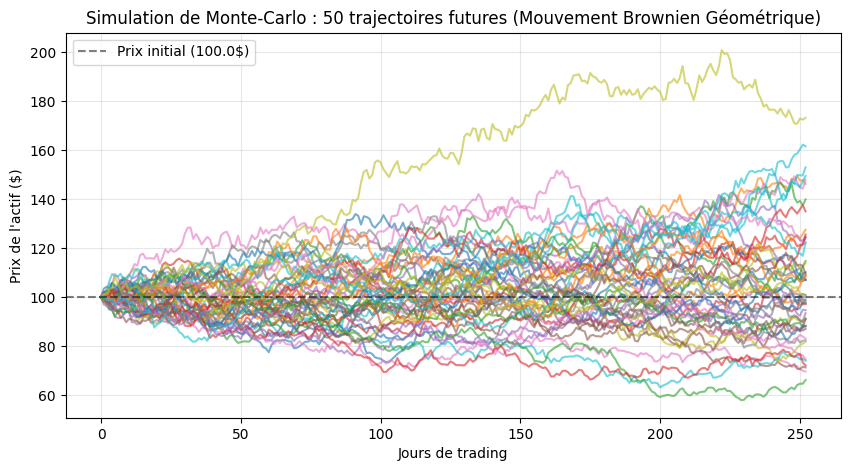

In [3]:
print("=== PARTIE 2 : SIMULATION DE MONTE-CARLO ===")

# Paramètres de la simulation (Ex: Action à forte croissance)
P0 = 100.0       # Prix initial
drift_annuel = 0.12  # Rendement annuel attendu (12%)
vol_annuelle = 0.25  # Volatilité annuelle (25%)
jours_trading = 252  # 1 an d'historique futur
simulations = 50     # Nombre de trajectoires à afficher

trajectoires = simulate_monte_carlo(P0, drift_annuel, vol_annuelle, jours_trading, simulations)

# Graphique des trajectoires de prix
plt.figure(figsize=(10, 5))
plt.plot(trajectoires, alpha=0.6)
plt.axhline(P0, color='black', linestyle='--', alpha=0.5, label=f'Prix initial ({P0}$)')
plt.title(f"Simulation de Monte-Carlo : {simulations} trajectoires futures (Mouvement Brownien Géométrique)")
plt.xlabel("Jours de trading")
plt.ylabel("Prix de l'actif ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
print("=== PARTIE 3 : CALCUL DES RENDEMENTS ===")
from numerical_tools import calculate_arithmetic_returns, calculate_log_returns

# On prend un échantillon de nos prix MC ou HF pour tester
prix_test = trajectoires[:, 0] # Première trajectoire de notre Monte-Carlo

ret_arith = calculate_arithmetic_returns(prix_test)
ret_log = calculate_log_returns(prix_test)

print(f"Nombre de prix analysés : {len(prix_test)}")
print(f"Nombre de rendements générés : {len(ret_arith)} (Normal, on perd le premier jour)")
print(f"Rendement arithmétique moyen : {np.mean(ret_arith)*100:.4f}%")
print(f"Rendement logarithmique moyen : {np.mean(ret_log)*100:.4f}%")

# Vérification de la propriété d'additivité des rendements log
print(f"\n-> Somme des rendements log : {np.sum(ret_log):.4f}")
print(f"-> Log du rendement global   : {np.log(prix_test[-1] / prix_test[0]):.4f}")

=== PARTIE 3 : CALCUL DES RENDEMENTS ===
Nombre de prix analysés : 253
Nombre de rendements générés : 252 (Normal, on perd le premier jour)
Rendement arithmétique moyen : 0.0370%
Rendement logarithmique moyen : 0.0269%

-> Somme des rendements log : 0.0678
-> Log du rendement global   : 0.0678


In [ ]:
" Code "

# .rolling(window=fenetre) : 
# "Rolling" signifie glissant. 
# Pandas va créer des sous-groupes de données. 
# Si ta fenetre est réglée sur 20, Pandas se place sur la 20ème ligne et regarde les 20 dernières lignes. 
# Puis il passe à la 21ème ligne, et regarde les 20 dernières, et ainsi de suite.

# .mean() : 
# On dit à Pandas : "Sur chaque sous-groupe de 20 prix que tu viens de cibler, calcule la moyenne."

# df['Moyenne_Rolling'] = ... : 
# On crée une toute nouvelle colonne dans notre tableau pour y stocker directement tous les résultats d'un coup.

In [ ]:
" 3 règles en Quant "


# 1.Tu ne boucleras point
# --> ne jamais écrire for i in range(len(df))
# --> toujours utiliser les fonctions intégrées de pandas ou numpy

# 2.Tu utiliseras les bons types de données
# --> Les flottants standard (float64) prennent de la place.
# --> passer en float32 divise par deux l'utilisation de ta mémoire RAM

# 3. Tu éviteras le "Chaining" : Faire df['Prix'][i] = ... 
# --> force Pandas à créer des copies cachées en mémoire
# --> Préfère toujours .loc ou .iloc.